<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/ML_Exp2_Dimension_Reduction_using_PCA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Why PCA is used for Dimensionality Reduction?

PCA is used for Dimensionality Reduction because it effectively simplifies a dataset by retaining the maximum amount of useful information while discarding redundant or less informative dimensions.

Key Reasons:

*  **Maximizes Variance**: PCA finds a new set of dimensions (Principal Components)
that are orthogonal (uncorrelated) and ordered so that the first component captures the largest possible variance in the original data, the second component captures the second largest, and so on. By keeping only the first few components, you retain the directions that explain most of the data's spread.

*  **Reduces Noise**: The components with the lowest variance often correspond to random noise or minor fluctuations. By discarding these components, PCA inherently acts as a noise-filtering mechanism, leading to a cleaner and potentially more robust dataset.

* **Addresses Multicollinearity:** The derived Principal Components are mathematically independent (orthogonal). This removes multicollinearity (high correlation between predictor variables), which can destabilize models like linear regression.

*  **Improves Computational Efficiency:** Reducing the number of features significantly decreases the time and memory required for model training. Models train faster and are less complex in the lower-dimensional space.

*  **Facilitates Visualization:** Data with three or more dimensions cannot be easily plotted. PCA allows you to reduce a high-dimensional dataset (e.g., 50 features) down to just 2 or 3 Principal Components, making it possible to visualize inherent clustering or structure in the data.


# Step 1: Import Libraries and Load Data

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# load dataset into Pandas DataFrame
df = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])

# **Why Standardization is required for PCA?**

* PCA requires standardization because it is sensitive to the scale of each variable; variables with larger ranges will dominate the principal components if not standardized.

* Standardization ensures all variables are centered (mean of zero) and have unit variance, allowing each to contribute equally to the analysis.

* This process prevents biased results, making the extracted components meaningful and interpretable regardless of original units or magnitudes.

* Standardization is especially necessary when variables differ in units (e.g., age in years, income in dollars) or numerical scale.

* Without standardization, PCA might overlook important patterns from variables with smaller variances, yielding misleading insights.

# Step 2: Separate Features and Standardize the Data

It preparing the Iris dataset for Principal Component Analysis (PCA) by separating the features from the target variable and standardizing the feature data.

It performs the necessary data preprocessing steps required before applying PCA:

**1. Select Features and Target**

**2. Standardize the Data**


In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['sepal length', 'sepal width', 'petal length', 'petal width']# 4 Features are reduced to 3 with one target value

# Separating out the features
x = df.loc[:, features].values

# Separating out the target
y = df.loc[:,['target']].values

# Standardizing the features
x = StandardScaler().fit_transform(x)

# Step 3: Compute Principal Components and Transform Data

 It performs the core operation of Principal Component Analysis (PCA), reducing the dimensionality of the standardized Iris dataset from 4 features down to 2 principal components.

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA with 2 components (reduce the dataset to 2D)
pca = PCA(n_components=2)
# Apply PCA transformation on the standardized data (x) and store the result
# fit_transform` will compute the principal components and apply the transformation to the data
principalComponents = pca.fit_transform(x)
# Create a new DataFrame with the 2 principal components
# The columns represent the two new dimensions (principal components)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])

# Step 4: Concatenate Principal Components with Target Variable

In [ ]:
finalDf = pd.concat([principalDf, df[['target']]], axis = 1)

# Step 5: Visualize the 2D Principal Component Projection


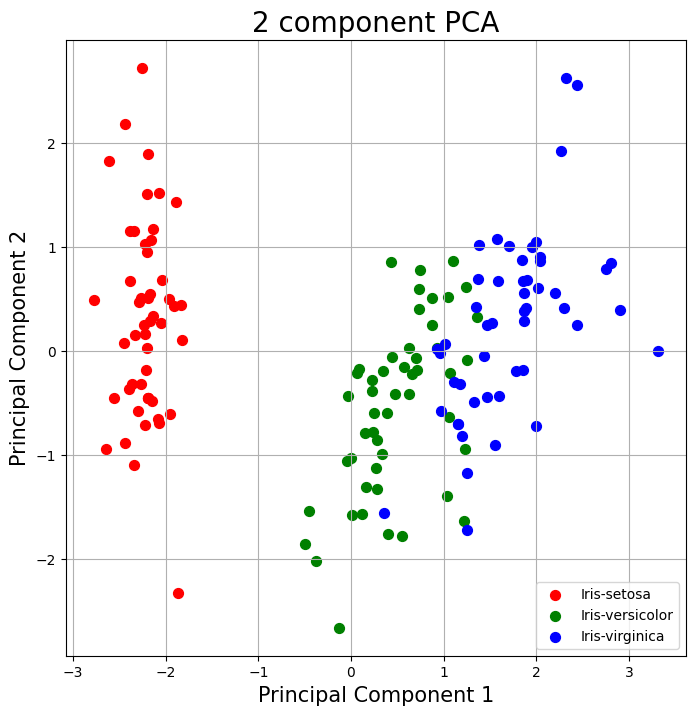

In [ ]:
import matplotlib.pyplot as plt
# Create a new figure with a specified size (8x8 inches)
fig = plt.figure(figsize = (8,8))
# Add a subplot to the figure (1 row, 1 column, 1st position)
ax = fig.add_subplot(1,1,1)
# Set the label for the x-axis
ax.set_xlabel('Principal Component 1', fontsize = 15)
# Set the label for the y-axis
ax.set_ylabel('Principal Component 2', fontsize = 15)
# Set the title of the plot
ax.set_title('2 component PCA', fontsize = 20)


# Define the targets (species) and corresponding colors for each species
targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
# Loop over each target (species) and its corresponding color
for target, color in zip(targets,colors):
# Filter the DataFrame to select only rows corresponding to the current species
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
# Add legend
ax.legend(targets)
# Show grid
ax.grid()

# Step 6: Calculate Explained Variance Ratio

In [ ]:
pca.explained_variance_ratio_

array([0.72770452, 0.23030523])

# **PART 2**

# Step 1: Import Libraries and Load Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_samples = int(input("Enter number of samples: "))
n_features = int(input("Enter number of features: "))

if n_features != 2:
    print("\nNote: Visualization is only available for 2 features.")
    # Visualization won't run properly if features != 2

print(f"\nEnter your data matrix ({n_samples} rows with {n_features} features each):")
data = []
for i in range(n_samples):
    while True:
        row_input = input(f"Row {i+1}: ")
        row_values = row_input.strip().split()
        if len(row_values) != n_features:
            print(f"Error: Expected {n_features} values, got {len(row_values)}. Please try again.")
            continue
        try:
            row = [float(val) for val in row_values]
            data.append(row)
            break
        except ValueError:
            print("Error: Please enter numeric values only.")

X = np.array(data)

print("\nOriginal Data:")
print(X)


Enter number of samples: 4
Enter number of features: 2

Enter your data matrix (4 rows with 2 features each):
Row 1: 4 11
Row 2: 2 8 
Row 3: 13 5
Row 4: 7 14

Original Data:
[[ 4. 11.]
 [ 2.  8.]
 [13.  5.]
 [ 7. 14.]]


# Step 2: Standardization skipped — using raw data directly

# Step 3: Compute Covariance Matrix

**Purpose of Covariance Matrix in PCA** - It quantifies the relationships (variance and covariance) between every pair of features in the dataset.


In [ ]:
cov_matrix = np.cov(X, rowvar=False)
print("\nCovariance Matrix:")
print(cov_matrix)


Covariance Matrix:
[[23. -8.]
 [-8. 15.]]


# Step 4: Compute Eigenvectors and Eigenvalues

**Why is it important for PCA?**
* **Determines Principal Component Directions:** The Eigenvectors are the specific linear combinations of the original features that define the new coordinate system. By calculating these vectors, PCA finds the directions of maximum variance in the data.

* **Quantifies Importance:** The Eigenvalues quantify how much variance each corresponding eigenvector captures. The larger the eigenvalue, the more significant that eigenvector (Principal Component) is.

* **Enables Sorting and Selection:** Computing the eigen-pairs allows you to sort the eigenvectors based on their eigenvalues in descending order. This process ranks the Principal Components from most important (PC1) to least important (PCn).

* **Facilitates Dimensionality Reduction:** Once sorted, you can decide which components to keep (those with high eigenvalues) and which to discard (those with low eigenvalues), achieving the core goal of dimensionality reduction with minimal information loss.

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors (columns):")
print(eigenvectors)


Eigenvalues:
[10.05572809 27.94427191]

Eigenvectors (columns):
[[-0.52573111 -0.85065081]
 [-0.85065081  0.52573111]]


# Step 5: Sort Eigenvalues in Descending Order

Sorting the eigenvalues is absolutely necessary because the size of the eigenvalue quantifies the variance captured by its corresponding Principal Component (PC). Sorting in descending order ranks the components from most informative (PC1) to least informative, allowing you to select the top k components to achieve effective dimensionality reduction while minimizing data loss.

In [ ]:
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("\nSorted Eigenvalues:")
print(eigenvalues)
print("\nSorted Eigenvectors (columns):")
print(eigenvectors)


Sorted Eigenvalues:
[27.94427191 10.05572809]

Sorted Eigenvectors (columns):
[[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]


# Step 6: Choose Principal Components

In [ ]:
while True:
    n_components = int(input(f"\nEnter number of principal components to keep (<= {n_features}): "))
    if 1 <= n_components <= n_features:
        break
    print("Invalid number of components, please try again.")

W = eigenvectors[:, :n_components]
print(f"\nSelected {n_components} Principal Components (columns):")
print(W)


Enter number of principal components to keep (<= 2): 1

Selected 1 Principal Components (columns):
[[-0.85065081]
 [ 0.52573111]]


# Step 7: Project Data Onto Lower-Dimensional Linear Subspace


Projected Data (first 5 samples) in 1D:
[[ 2.380439  ]
 [ 2.50454728]
 [-8.42980495]
 [ 1.40567991]]


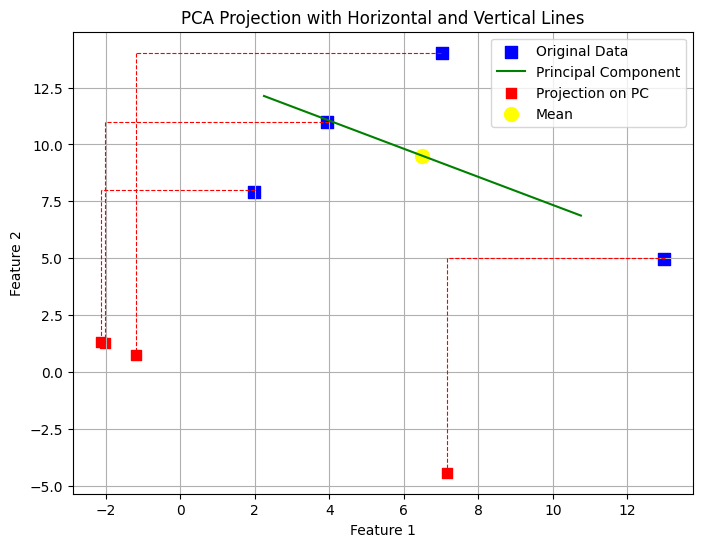

In [ ]:
X_pca = X.dot(W)
print(f"\nProjected Data (first 5 samples) in {n_components}D:")
print(X_pca[:5])

# Visualization (only if 2 features and 1 component)
if n_features == 2 and n_components == 1:
    # Project back to original space (reconstruction on PC line)
    X_proj_back = X_pca.dot(W.T)  # shape: (n_samples x 2)

    mean_X = np.mean(X, axis=0)
    pc_vector = W[:, 0]

    plt.figure(figsize=(8,6))


    # Add jitter for original data so points don’t overlap exactly with projections
    jitter = 0.1
    X_jittered = X + np.random.uniform(-jitter, jitter, X.shape)

    # Plot jittered original data points (blue squares)
    plt.scatter(X_jittered[:, 0], X_jittered[:, 1], color='blue', marker='s', label='Original Data', s=70)

    # Plot principal component line (green)
    line_points = np.array([mean_X - 5*pc_vector, mean_X + 5*pc_vector])
    plt.plot(line_points[:, 0], line_points[:, 1], color='green', label='Principal Component')

    # Plot projected points (red squares)
    plt.scatter(X_proj_back[:, 0], X_proj_back[:, 1], color='red', marker='s', label='Projection on PC', s=50)

    # Highlight mean point (yellow circle)
    plt.scatter(*mean_X, color='yellow', s=100, label='Mean')

    # Draw horizontal and vertical red dashed lines
for i in range(X.shape[0]):
    plt.plot([X[i, 0], X_proj_back[i, 0]], [X[i, 1], X[i, 1]], color='red', linestyle='--', linewidth=0.8)
    plt.plot([X_proj_back[i, 0], X_proj_back[i, 0]], [X[i, 1], X_proj_back[i, 1]], color='red', linestyle='--', linewidth=0.8)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PCA Projection with Horizontal and Vertical Lines')
plt.legend()
plt.grid(True)
plt.show()
